In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread

%matplotlib inline

In [10]:
face_dir = r"/content/FacePhoto"
mask_dir = r"/content/GroundT_FacePhoto"

In [11]:
def load_images(image_folder, mask_folder):
    images = []
    masks = []
    names = []

    image_files = os.listdir(image_folder)
    mask_files = os.listdir(mask_folder)

    for img_file in image_files:
        name = os.path.splitext(img_file)[0]

        for mask_file in mask_files:
            mask_name = os.path.splitext(mask_file)[0]

            if name == mask_name:
                img_path = os.path.join(image_folder, img_file)
                mask_path = os.path.join(mask_folder, mask_file)

                image = imread(img_path)
                mask = imread(mask_path)

                images.append(image)
                masks.append(mask)
                names.append(img_file)
                break

    return images, masks, names

In [12]:
def extract_skin(image, mask):
    mask_rgb = mask[:, :, :3]

    # Identify white pixels in mask (skin)
    skin_pixels = np.all(mask_rgb == [255, 255, 255], axis=-1)

    skin_image = np.zeros_like(image)
    skin_image[skin_pixels] = image[skin_pixels]

    return skin_image, skin_pixels

In [13]:
def display_results(image, mask, skin_image, name):
    plt.figure(figsize=(12, 8))

    # Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    # Mask
    plt.subplot(2, 2, 2)
    plt.imshow(mask)
    plt.title("Mask")
    plt.axis("off")

    # Overlay
    plt.subplot(2, 2, 3)
    plt.imshow(image)
    plt.imshow(mask, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    # Extracted Skin
    plt.subplot(2, 2, 4)
    plt.imshow(skin_image)
    plt.title("Extracted Skin")
    plt.axis("off")

    plt.suptitle(name)
    plt.show()

In [14]:
images, masks, names = load_images(face_dir, mask_dir)

print("Number of Face Images Loaded:", len(images))

/tmp/ipykernel_25275/61964665.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(img_path)
/tmp/ipykernel_25275/61964665.py:20: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imread(mask_path)


Number of Face Images Loaded: 32


Image: m_unsexy_gr.jpg
Skin Pixels: 52436
Skin Percentage: 40.97%
--------------------------------


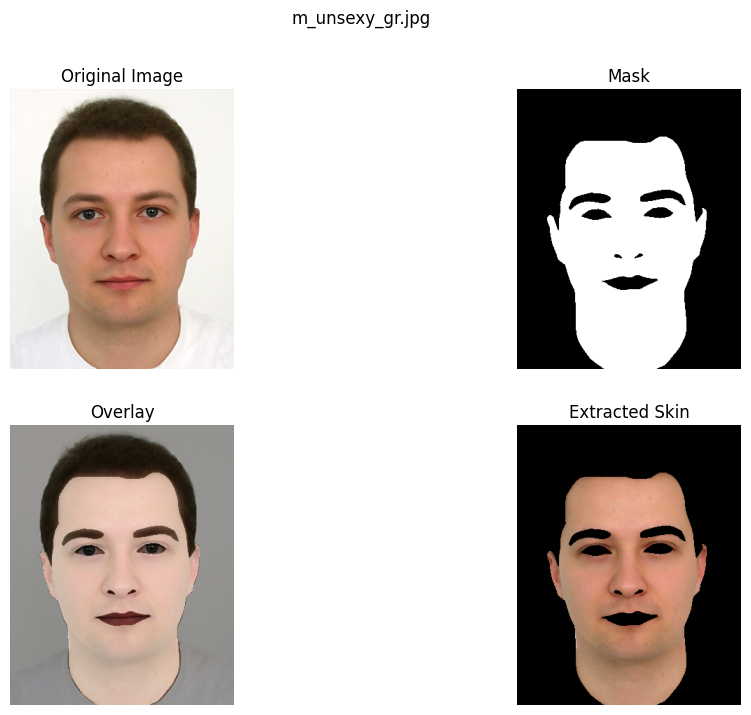

Image: Matthew_narrowweb__300x381,0.jpg
Skin Pixels: 48389
Skin Percentage: 42.34%
--------------------------------


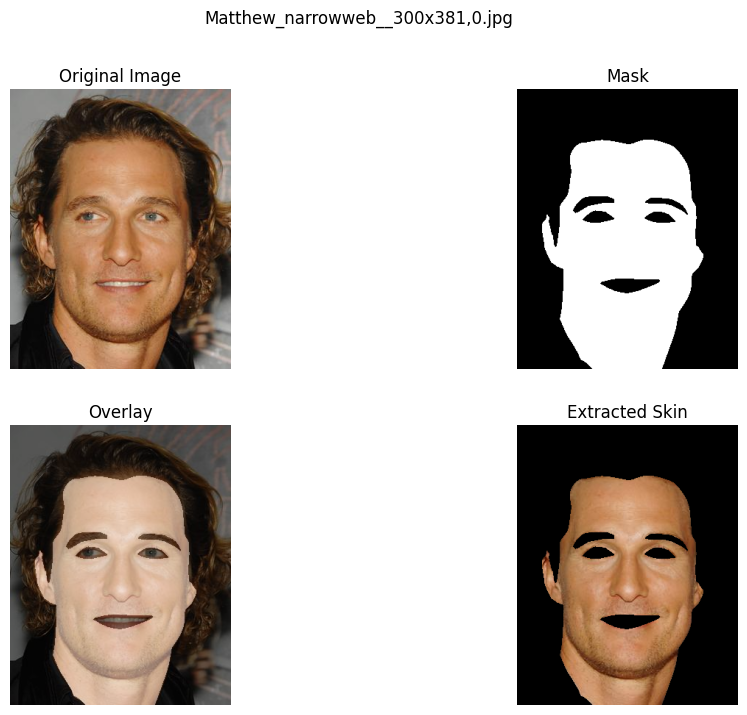

Image: pic447a1uu2.jpg
Skin Pixels: 18748
Skin Percentage: 19.70%
--------------------------------


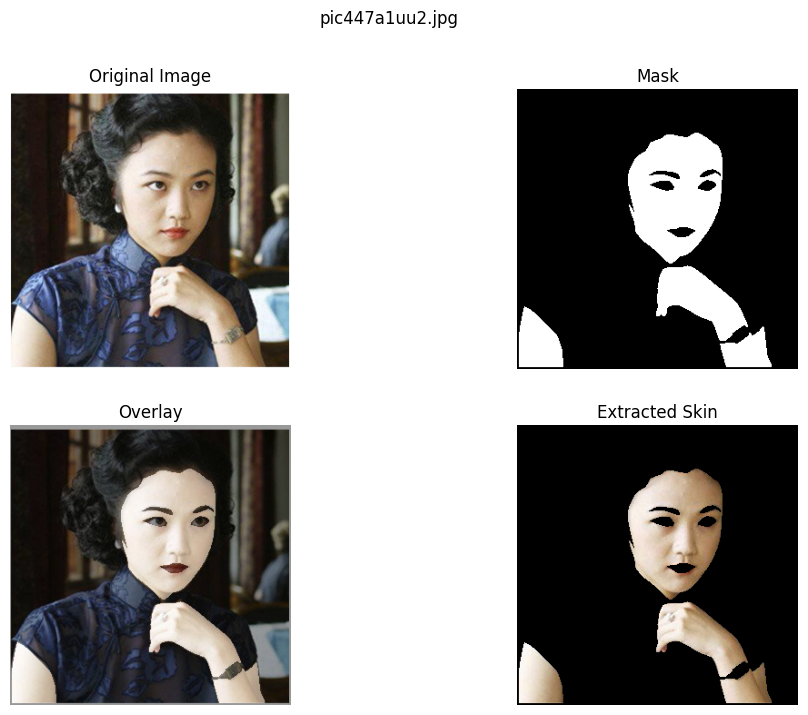

In [16]:
for i in range(len(images)):
    image = images[i]
    mask = masks[i]
    name = names[i]

    skin_image, skin_pixels = extract_skin(image, mask)

    total_pixels = skin_pixels.size
    skin_count = np.sum(skin_pixels)
    skin_percentage = (skin_count / total_pixels) * 100

    print("Image:", name)
    print("Skin Pixels:", skin_count)
    print("Skin Percentage: %.2f%%" % skin_percentage)
    print("--------------------------------")

    display_results(image, mask, skin_image, name)

    # Show only first 3 images
    if i == 2:
        break